# 🏦 Fannie Mae Mortgage Default Prediction
## Machine Learning Project with Full MLflow Integration
---
**Dataset:** Fannie Mae Loan Performance Data  
**Target Variable:** `is_default` (0 = No Default, 1 = Default)  
**Task:** Binary Classification  

### Project Pipeline:
1. Exploratory Data Analysis (EDA)
2. Data Cleaning
3. Data Preparation
4. Baseline Model → MLflow Run 1
5. Best Model Selection → MLflow Run 2
6. Hyperparameter Tuning → MLflow Run 3
7. Ensemble Learning → MLflow Run 4
8. Data Improvement + Feature Engineering + PCA → MLflow Run 5

## 📦 Step 0: Import Libraries & Setup MLflow

In [12]:
import sys
if 'google.colab' in sys.modules:
  %pip install mlflow

# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── MLflow ───────────────────────────────────────────────────────────────────
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    BaggingClassifier, AdaBoostClassifier,
    VotingClassifier, StackingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Imbalanced Learning ───────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── MLflow Experiment Setup ───────────────────────────────────────────────────
EXPERIMENT_NAME = "Fannie_Mae_Default_Prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

print("✅ All libraries imported successfully!")
print(f"📊 MLflow Experiment: '{EXPERIMENT_NAME}' is ready.")
print(f"🔢 MLflow Tracking URI: {mlflow.get_tracking_uri()}")

✅ All libraries imported successfully!
📊 MLflow Experiment: 'Fannie_Mae_Default_Prediction' is ready.
🔢 MLflow Tracking URI: sqlite:////content/mlflow.db


---
## 🔍 Step 1: Exploratory Data Analysis (EDA)

In [13]:
from google.colab import files
import os

# Upload the CSV file
print('Please upload the Mldata_fannie_mae_df.csv file:')
uploaded = files.upload()

# Verify if the file was uploaded
if 'Mldata_fannie_mae_df.csv' in uploaded:
    print('File Mldata_fannie_mae_df.csv uploaded successfully!')
else:
    print('File upload failed or file not found. Please try again.')

Please upload the Mldata_fannie_mae_df.csv file:


Saving Mldata_fannie_mae_df.csv to Mldata_fannie_mae_df.csv
File Mldata_fannie_mae_df.csv uploaded successfully!


In [14]:
# Load dataset
df = pd.read_csv("Mldata_fannie_mae_df.csv")

print("═" * 60)
print(f"📐 Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("═" * 60)
df.head()

════════════════════════════════════════════════════════════
📐 Dataset Shape : 7,902 rows × 34 columns
════════════════════════════════════════════════════════════


,ORIG_CHN,orig_rt,orig_amt,orig_trm,oltv,ocltv,num_bo,dti,CSCORE_B,FTHB_FLG,...,MOD_FLAG,MODTRM_CHNG,MODUPB_CHNG,CSCORE_MN,ORIG_VAL,LAST_DTE,LAST_STAT,is_default,loan_to_income_ratio,loan_age_months
0,2,3.875,43000,120,80,80,1,34.0,708.0,0,...,0,0,0,708.0,53750.00,2022-09-01,C,0,1264.705882,79
1,2,3.625,219000,360,95,95,1,39.0,748.0,0,...,0,0,0,748.0,230526.32,2019-11-01,P,0,5615.384615,45
2,2,4.375,416000,360,95,95,2,30.0,657.0,0,...,1,1,1,651.0,437894.74,2022-09-01,1,1,13866.666667,79
3,2,4.000,259000,360,70,70,1,43.0,772.0,0,...,0,0,0,772.0,370000.00,2017-12-01,P,0,6023.255814,22
4,1,2.875,400000,180,69,69,1,37.0,737.0,0,...,0,0,0,737.0,579710.14,2022-09-01,C,0,10810.810811,79


In [15]:
print("📋 Column Data Types:")
print(df.dtypes)
print()
print("❌ Missing Values Per Column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None — Clean Dataset!")

📋 Column Data Types:
ORIG_CHN                  int64
orig_rt                 float64
orig_amt                  int64
orig_trm                  int64
oltv                      int64
ocltv                     int64
num_bo                    int64
dti                     float64
CSCORE_B                float64
FTHB_FLG                  int64
purpose                   int64
PROP_TYP                  int64
NUM_UNIT                  int64
occ_stat                  int64
state                    object
zip_3                     int64
relo_flg                  int64
MI_TYPE                   int64
AQSN_DTE                 object
ORIG_DTE                 object
FRST_DTE                 object
LAST_RT                 float64
msa                       int64
LAST_ACTIVITY_DATE       object
MOD_FLAG                  int64
MODTRM_CHNG               int64
MODUPB_CHNG               int64
CSCORE_MN               float64
ORIG_VAL                float64
LAST_DTE                 object
LAST_STAT          

In [16]:
print("📈 Statistical Summary (Numeric Columns):")
df.describe().T

📈 Statistical Summary (Numeric Columns):


,count,mean,std,min,25%,50%,75%,max
ORIG_CHN,7902.0,1.496583,0.673641,0.000000,1.0000,2.000000,2.00000,2.000
orig_rt,7902.0,4.073069,0.483410,2.500000,3.7500,4.125000,4.37500,5.625
orig_amt,7902.0,216229.688686,118766.393756,16000.000000,124000.0000,192000.000000,290000.00000,910000.000
orig_trm,7902.0,324.790939,70.978532,96.000000,360.0000,360.000000,360.00000,360.000
oltv,7902.0,76.045811,16.403675,7.000000,69.0000,80.000000,90.00000,97.000
ocltv,7902.0,76.661478,16.516055,7.000000,69.0000,80.000000,90.00000,105.000
num_bo,7902.0,1.420400,0.513756,1.000000,1.0000,1.000000,2.00000,4.000
dti,7902.0,34.454189,8.658076,3.000000,28.0000,36.000000,42.00000,50.000
CSCORE_B,7902.0,734.624779,52.203287,620.000000,693.0000,740.000000,781.00000,826.000
FTHB_FLG,7902.0,0.241584,0.428071,0.000000,0.0000,0.000000,0.00000,1.000


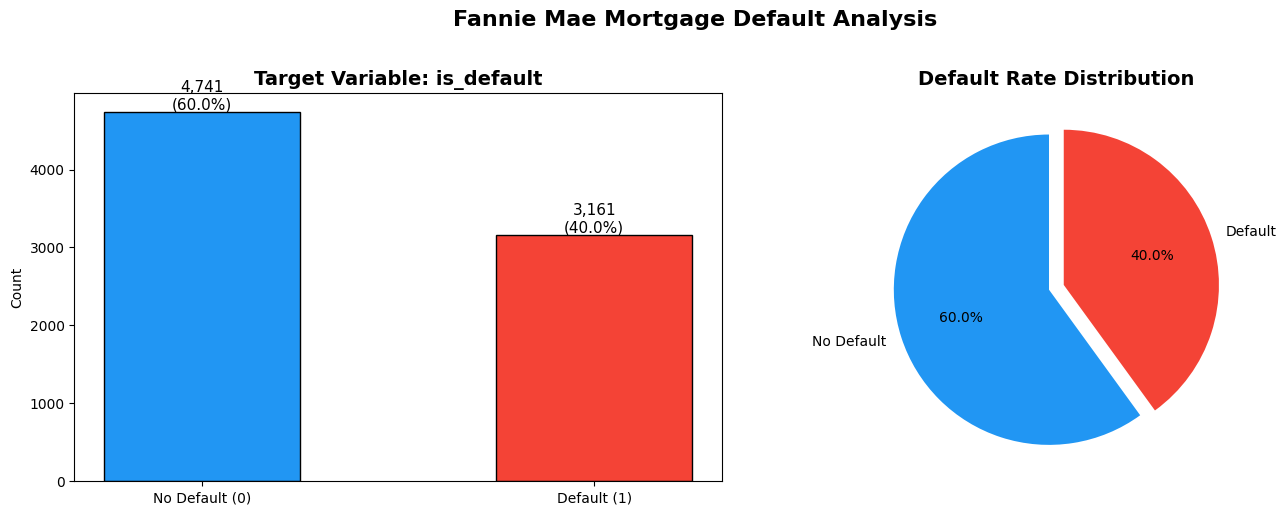


⚖️  Class Imbalance Ratio  →  Non-Default : Default = 1.50 : 1


In [17]:
# ── Target Distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['is_default'].value_counts()
colors = ['#2196F3', '#F44336']

axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Variable: is_default', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['No Default', 'Default'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Default Rate Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Fannie Mae Mortgage Default Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n⚖️  Class Imbalance Ratio  →  Non-Default : Default = {counts[0]/counts[1]:.2f} : 1")

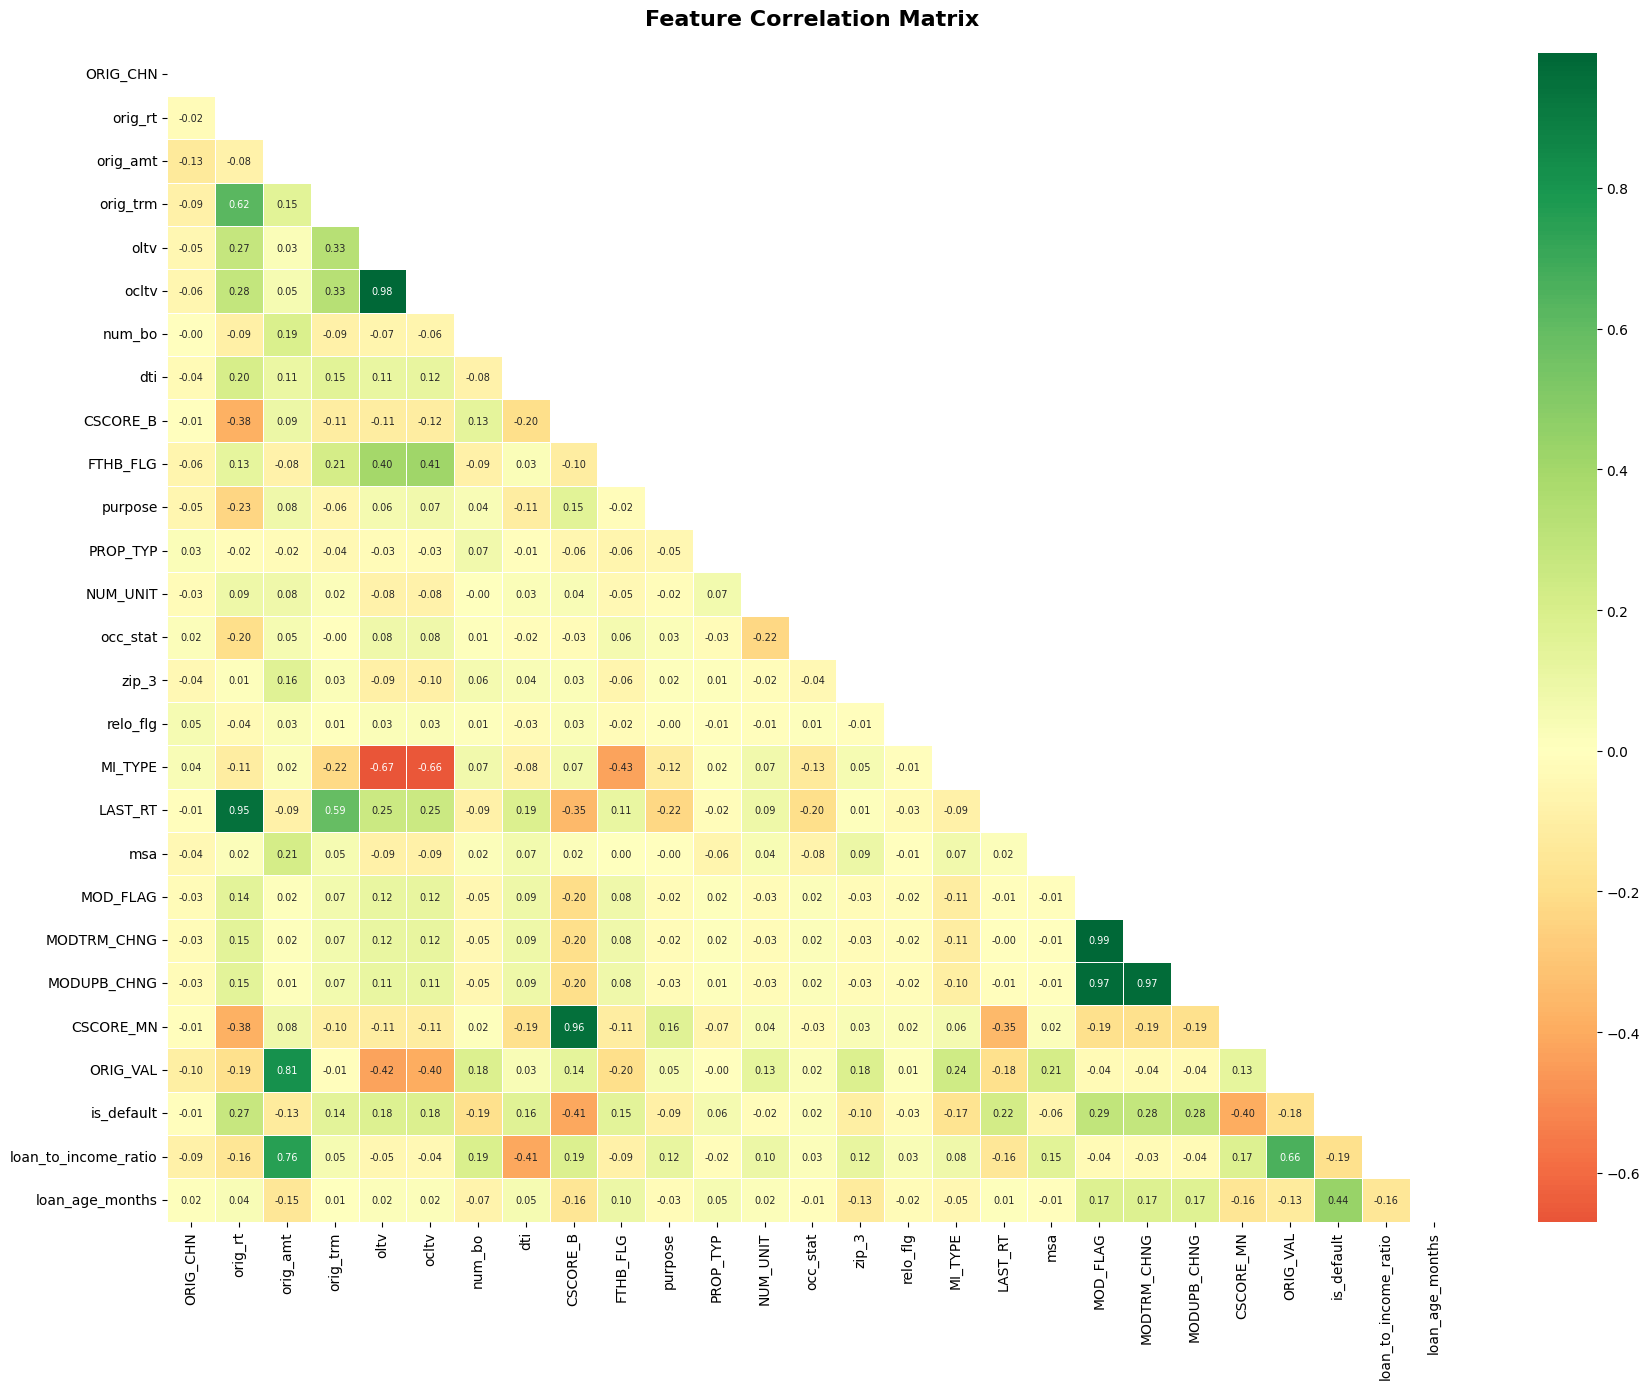

In [18]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(18, 14))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

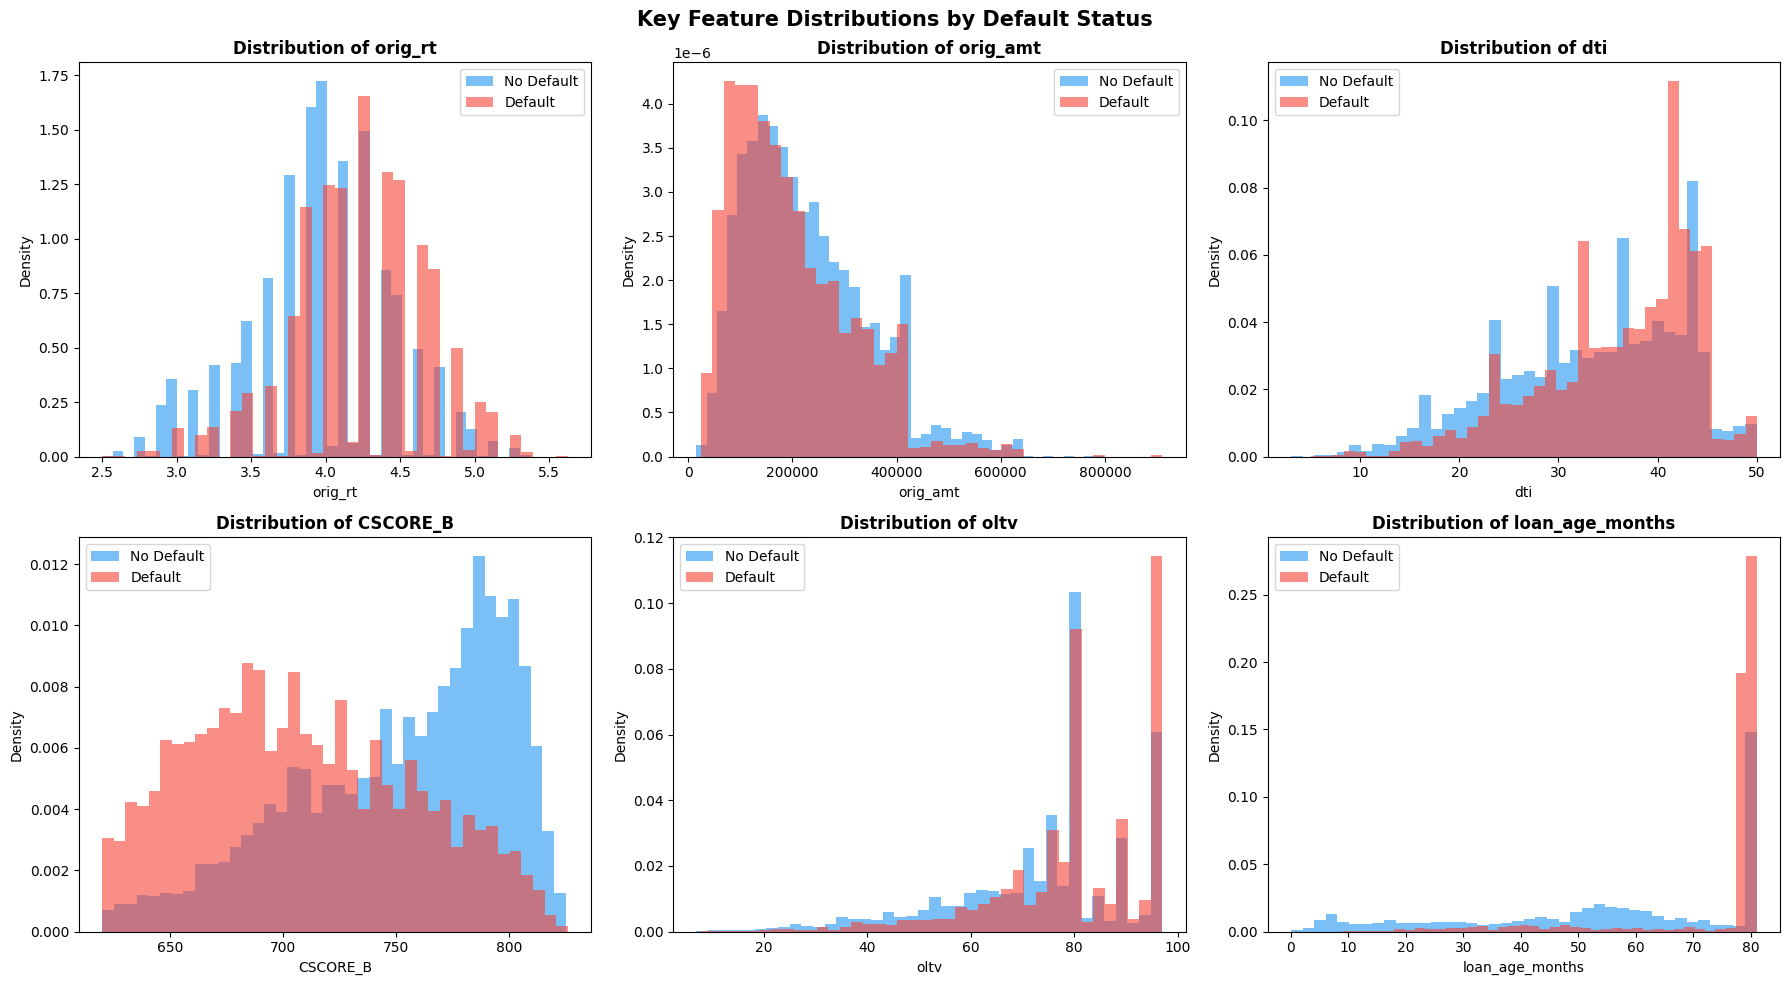

In [19]:
# ── Key Feature Distributions by Default Status ──────────────────────────────
key_features = ['orig_rt', 'orig_amt', 'dti', 'CSCORE_B', 'oltv', 'loan_age_months']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for status, color, label in zip([0, 1], ['#2196F3', '#F44336'], ['No Default', 'Default']):
        axes[i].hist(df[df['is_default'] == status][feat].dropna(),
                     bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(f'Distribution of {feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Key Feature Distributions by Default Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

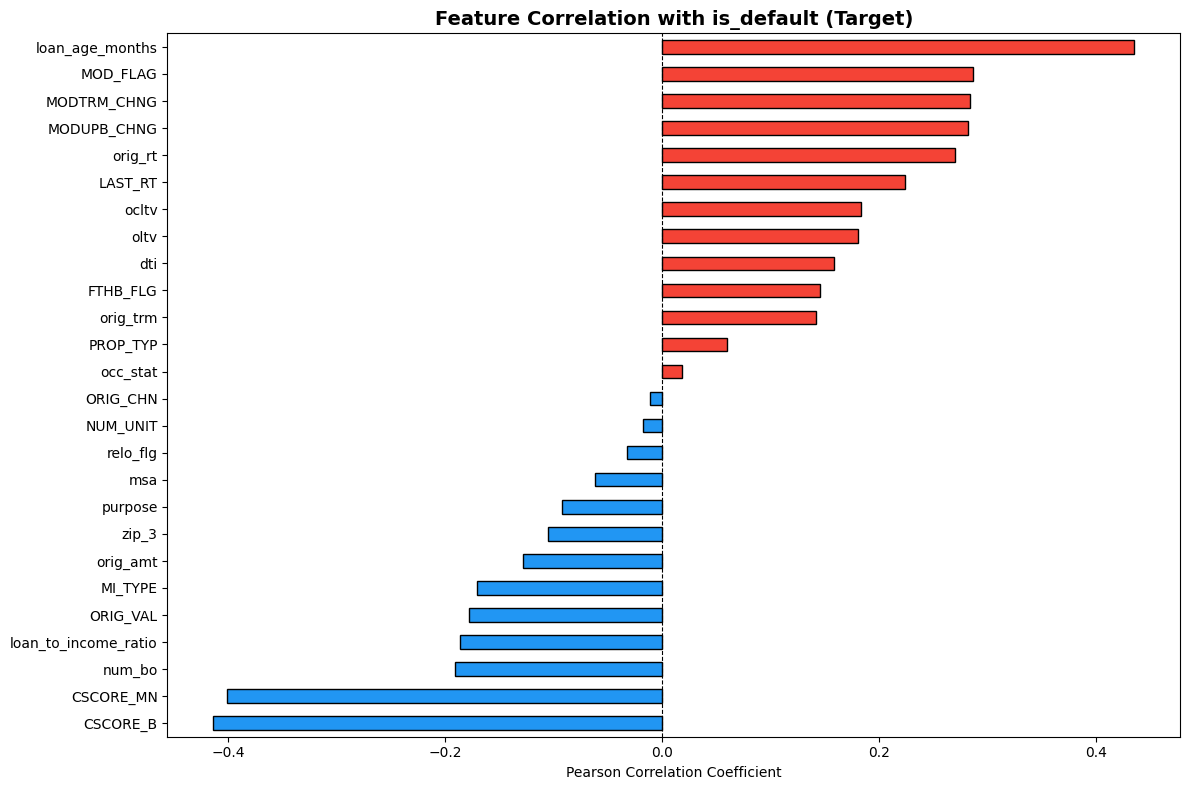

🔴 Red = positive correlation (increases default risk)
🔵 Blue = negative correlation (reduces default risk)


In [20]:
# ── Correlation with Target ───────────────────────────────────────────────────
target_corr = df[numeric_cols].corr()['is_default'].drop('is_default').sort_values()

plt.figure(figsize=(12, 8))
colors_bar = ['#F44336' if v > 0 else '#2196F3' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors_bar, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with is_default (Target)', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('eda_target_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print("🔴 Red = positive correlation (increases default risk)")
print("🔵 Blue = negative correlation (reduces default risk)")

---
## 🧹 Step 2: Data Cleaning

In [21]:
df_clean = df.copy()

# ── Drop High-Cardinality / ID-like Columns ───────────────────────────────────
# Dates: convert origination date to year/month features, then drop raw strings
date_cols = ['AQSN_DTE', 'ORIG_DTE', 'FRST_DTE', 'LAST_DTE', 'LAST_ACTIVITY_DATE']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

df_clean['orig_year']  = df_clean['ORIG_DTE'].dt.year
df_clean['orig_month'] = df_clean['ORIG_DTE'].dt.month
df_clean['last_year']  = df_clean['LAST_DTE'].dt.year
df_clean['last_month'] = df_clean['LAST_DTE'].dt.month

# Drop raw date columns
df_clean.drop(columns=date_cols, inplace=True)

# ── Encode LAST_STAT (ordinal status column) ──────────────────────────────────
last_stat_map = {'C': 0, 'P': 1, '1': 2, '2': 3, '3': 4,
                 '4': 5, '5': 6, '6': 7, '8': 8, '9': 9, 'F': 10}
df_clean['LAST_STAT'] = df_clean['LAST_STAT'].map(last_stat_map).fillna(-1).astype(int)

# ── Encode 'state' (categorical) ─────────────────────────────────────────────
le = LabelEncoder()
df_clean['state_enc'] = le.fit_transform(df_clean['state'].astype(str))
df_clean.drop(columns=['state'], inplace=True)

# ── Remove Extreme Outliers in loan_to_income_ratio ───────────────────────────
q_high = df_clean['loan_to_income_ratio'].quantile(0.99)
df_clean['loan_to_income_ratio'] = df_clean['loan_to_income_ratio'].clip(upper=q_high)

# ── Drop duplicates ───────────────────────────────────────────────────────────
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"✅ Duplicates removed: {before - len(df_clean)}")
print(f"✅ Dataset after cleaning: {df_clean.shape}")
print(f"✅ Missing values remaining: {df_clean.isnull().sum().sum()}")

✅ Duplicates removed: 0
✅ Dataset after cleaning: (7902, 33)
✅ Missing values remaining: 0


---
## ⚙️ Step 3: Data Preparation

In [22]:
# ── Feature / Target Split ────────────────────────────────────────────────────
TARGET = 'is_default'
# Drop columns leaking the target or that are post-event indicators
drop_cols = [TARGET, 'LAST_STAT', 'MOD_FLAG', 'MODTRM_CHNG', 'MODUPB_CHNG',
             'LAST_RT', 'last_year', 'last_month']
X = df_clean.drop(columns=drop_cols)
y = df_clean[TARGET]

print(f"📐 Feature matrix X : {X.shape}")
print(f"🎯 Target vector y  : {y.shape}")
print(f"\n📋 Features used ({len(X.columns)}):")
print(X.columns.tolist())

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Feature Scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Train set : {X_train.shape}")
print(f"✅ Test set  : {X_test.shape}")

📐 Feature matrix X : (7902, 25)
🎯 Target vector y  : (7902,)

📋 Features used (25):
['ORIG_CHN', 'orig_rt', 'orig_amt', 'orig_trm', 'oltv', 'ocltv', 'num_bo', 'dti', 'CSCORE_B', 'FTHB_FLG', 'purpose', 'PROP_TYP', 'NUM_UNIT', 'occ_stat', 'zip_3', 'relo_flg', 'MI_TYPE', 'msa', 'CSCORE_MN', 'ORIG_VAL', 'loan_to_income_ratio', 'loan_age_months', 'orig_year', 'orig_month', 'state_enc']

✅ Train set : (6321, 25)
✅ Test set  : (1581, 25)


In [23]:
# ── Helper: Unified Metrics Logger ────────────────────────────────────────────
def compute_metrics(model, X_tr, y_tr, X_te, y_te, use_proba=True):
    """Compute train & test metrics. Returns dict."""
    y_pred  = model.predict(X_te)
    y_train_pred = model.predict(X_tr)

    if use_proba and hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_prob)
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
        auc = roc_auc_score(y_te, y_prob)
    else:
        auc = 0.0

    return {
        'train_accuracy' : accuracy_score(y_tr, y_train_pred),
        'test_accuracy'  : accuracy_score(y_te, y_pred),
        'precision'      : precision_score(y_te, y_pred, zero_division=0),
        'recall'         : recall_score(y_te, y_pred, zero_division=0),
        'f1_score'       : f1_score(y_te, y_pred, zero_division=0),
        'roc_auc'        : auc
    }

# Trusted types for newer MLflow versions (avoids skops security warning)
TRUSTED_TYPES = [
    'collections.OrderedDict', 'lightgbm.basic.Booster',
    'lightgbm.sklearn.LGBMClassifier', 'sklearn.utils._bunch.Bunch',
    'sklearn.linear_model._logistic.LogisticRegression',
    'sklearn.ensemble._forest.RandomForestClassifier',
    'sklearn.ensemble._voting.VotingClassifier',
    'sklearn.ensemble._stacking.StackingClassifier',
    'sklearn.tree._classes.DecisionTreeClassifier',
    'sklearn.ensemble._bagging.BaggingClassifier',
    'sklearn.ensemble._weight_boosting.AdaBoostClassifier',
]

def log_metrics_and_model(run_name, model, metrics, params,
                           X_te, y_te, flavor='sklearn'):
    """Log everything to MLflow; return the run ID."""
    with mlflow.start_run(run_name=run_name) as run:
        # Log parameters
        mlflow.log_params(params)
        # Log metrics
        mlflow.log_metrics(metrics)
        # Log model (with trusted types for MLflow >= 2.14)
        try:
            if flavor == 'xgboost':
                mlflow.xgboost.log_model(model, artifact_path='model')
            elif flavor == 'lightgbm':
                mlflow.lightgbm.log_model(model, artifact_path='model')
            else:
                mlflow.sklearn.log_model(model, artifact_path='model',
                                         skops_trusted_types=TRUSTED_TYPES)
        except Exception as e:
            print(f"  [warn] Could not save model artifact: {e}")

        # Confusion matrix figure
        y_pred = model.predict(X_te)
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f'{run_name}\nConfusion Matrix')
        plt.tight_layout()
        fig_path = f'cm_{run_name.replace(" ","_")}.png'
        plt.savefig(fig_path, dpi=120)
        mlflow.log_artifact(fig_path)
        plt.show()
        plt.close(fig)

        run_id = run.info.run_id
    return run_id

run_results = []   # we'll store (run_name, metrics, run_id) here
print("✅ Helper functions defined.")

✅ Helper functions defined.


---
## 🏃 MLflow Run 1 — Baseline: Simple Logistic Regression
> **Goal:** Establish a reference point before any improvement.

════════════════════════════════════════════════════════════
 🚀  MLflow RUN 1 : BASELINE — Logistic Regression
════════════════════════════════════════════════════════════


2026/07/25 18:54:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


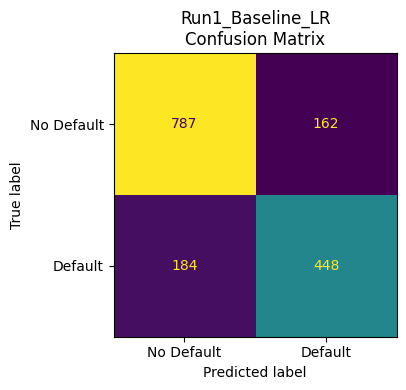


📊 Baseline Logistic Regression Results:
   train_accuracy      : 0.7999
   test_accuracy       : 0.7812
   precision           : 0.7344
   recall              : 0.7089
   f1_score            : 0.7214
   roc_auc             : 0.8522

🔗 MLflow Run ID: b67b2d7ed97246078f67500c3f33a088


In [24]:
print("═" * 60)
print(" 🚀  MLflow RUN 1 : BASELINE — Logistic Regression")
print("═" * 60)

lr_params = {'model': 'LogisticRegression', 'C': 1.0,
             'max_iter': 300, 'solver': 'lbfgs', 'run_type': 'baseline'}

lr_model = LogisticRegression(C=1.0, max_iter=300, random_state=42)
lr_model.fit(X_train_sc, y_train)

lr_metrics = compute_metrics(lr_model, X_train_sc, y_train, X_test_sc, y_test)

run_id_1 = log_metrics_and_model(
    run_name   = "Run1_Baseline_LR",
    model      = lr_model,
    metrics    = lr_metrics,
    params     = lr_params,
    X_te       = X_test_sc,
    y_te       = y_test
)
run_results.append(('Run1 – Baseline LR', lr_metrics, run_id_1))

print(f"\n📊 Baseline Logistic Regression Results:")
for k, v in lr_metrics.items():
    print(f"   {k:20s}: {v:.4f}")
print(f"\n🔗 MLflow Run ID: {run_id_1}")

---
## 🏃 MLflow Run 2 — Best Model Selection
> **Goal:** Compare multiple algorithms to find the strongest candidate.

2026/07/25 18:55:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


════════════════════════════════════════════════════════════
 🔍  MLflow RUN 2 : Multi-Model Comparison
════════════════════════════════════════════════════════════
  Training Decision Tree ... 

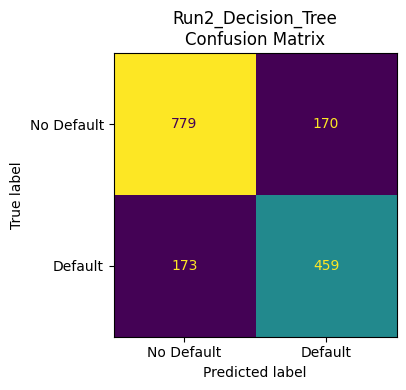

F1=0.7280 | ROC-AUC=0.8288
  Training Random Forest ... 

2026/07/25 18:55:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


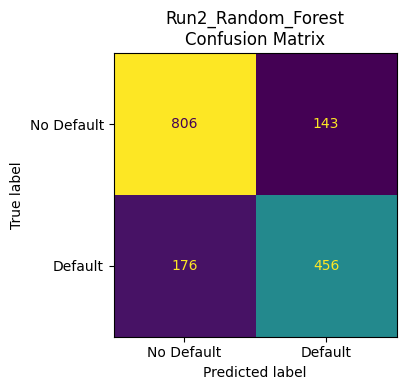

F1=0.7409 | ROC-AUC=0.8814
  Training XGBoost ... 

2026/07/25 18:56:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


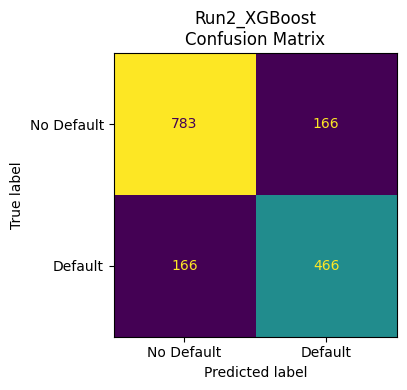

F1=0.7373 | ROC-AUC=0.8708
  Training LightGBM ... 

2026/07/25 18:56:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


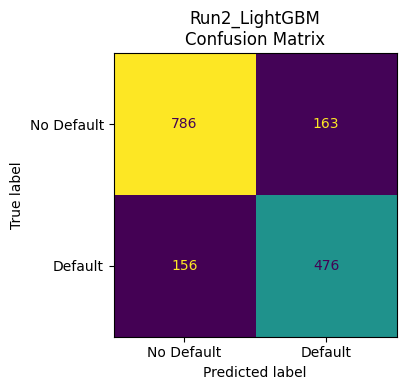

F1=0.7490 | ROC-AUC=0.8841
  Training Gradient Boost ... 

2026/07/25 18:56:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


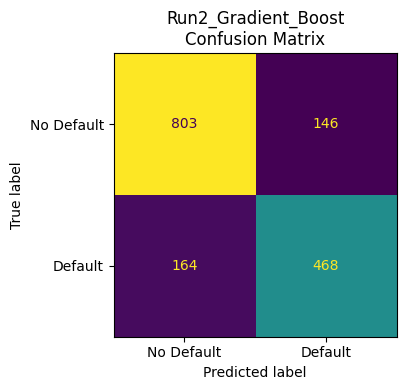

F1=0.7512 | ROC-AUC=0.8906


<Figure size 1200x500 with 0 Axes>

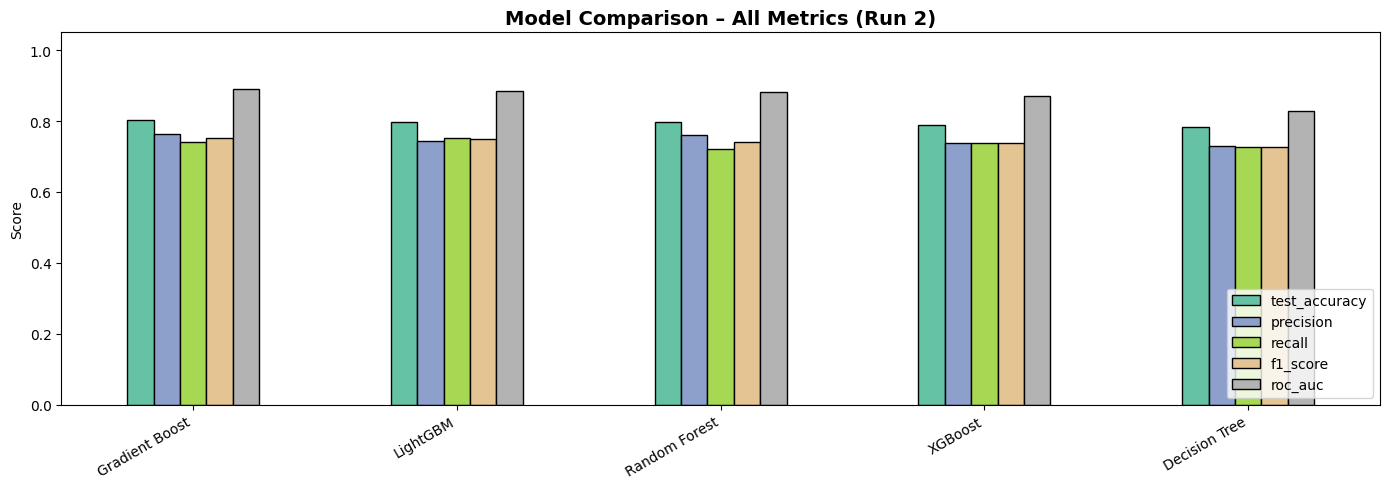


🏆 Best Model by ROC-AUC: Gradient Boost
                train_accuracy  test_accuracy  precision    recall  f1_score  \
Gradient Boost        0.846385       0.803922   0.762215  0.740506  0.751204   
LightGBM              0.922955       0.798229   0.744914  0.753165  0.749017   
Random Forest         1.000000       0.798229   0.761269  0.721519  0.740861   
XGBoost               0.986078       0.790006   0.737342  0.737342  0.737342   
Decision Tree         0.868850       0.783049   0.729730  0.726266  0.727994   

                 roc_auc  
Gradient Boost  0.890619  
LightGBM        0.884122  
Random Forest   0.881441  
XGBoost         0.870797  
Decision Tree   0.828763  


In [25]:
print("═" * 60)
print(" 🔍  MLflow RUN 2 : Multi-Model Comparison")
print("═" * 60)

candidate_models = {
    'Decision Tree'  : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'  : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'        : XGBClassifier(n_estimators=100, use_label_encoder=False,
                                     eval_metric='logloss', random_state=42),
    'LightGBM'       : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'Gradient Boost' : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

comparison_results = {}

for name, model in candidate_models.items():
    print(f"  Training {name} ...", end=' ')
    model.fit(X_train_sc, y_train)
    m = compute_metrics(model, X_train_sc, y_train, X_test_sc, y_test)
    comparison_results[name] = m

    flavor = 'xgboost' if 'XGBoost' in name else ('lightgbm' if 'LightGBM' in name else 'sklearn')
    log_metrics_and_model(
        run_name = f"Run2_{name.replace(' ','_')}",
        model    = model,
        metrics  = m,
        params   = {'model': name, 'run_type': 'model_selection', 'n_estimators': 100},
        X_te     = X_test_sc,
        y_te     = y_test,
        flavor   = flavor
    )
    print(f"F1={m['f1_score']:.4f} | ROC-AUC={m['roc_auc']:.4f}")

# ── Comparison Table ──────────────────────────────────────────────────────────
comp_df = pd.DataFrame(comparison_results).T
comp_df = comp_df.sort_values('roc_auc', ascending=False)

plt.figure(figsize=(12, 5))
comp_df[['test_accuracy','precision','recall','f1_score','roc_auc']].plot(
    kind='bar', figsize=(14, 5), edgecolor='black', colormap='Set2')
plt.title('Model Comparison – All Metrics (Run 2)', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('run2_model_comparison.png', dpi=150)
plt.show()

best_model_name = comp_df['roc_auc'].idxmax()
print(f"\n🏆 Best Model by ROC-AUC: {best_model_name}")
print(comp_df)

---
## 🏃 MLflow Run 3 — Hyperparameter Tuning on Best Model
> **Goal:** Push the winning model further with RandomizedSearchCV.

════════════════════════════════════════════════════════════
 🎛️  MLflow RUN 3 : Hyperparameter Tuning — XGBoost
════════════════════════════════════════════════════════════
Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/07/25 18:57:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✅ Best CV ROC-AUC : 0.8955
✅ Best Params     : {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}


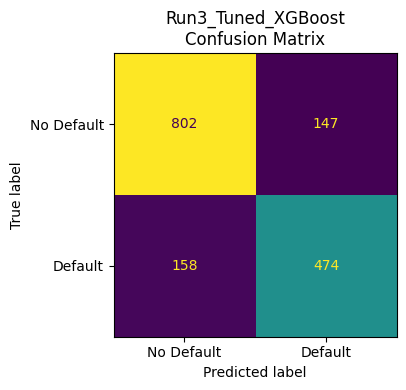


📊 Tuned XGBoost Results:
   train_accuracy      : 0.8567
   test_accuracy       : 0.8071
   precision           : 0.7633
   recall              : 0.7500
   f1_score            : 0.7566
   roc_auc             : 0.8934


In [26]:
print("═" * 60)
print(" 🎛️  MLflow RUN 3 : Hyperparameter Tuning — XGBoost")
print("═" * 60)

xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3],
    'reg_alpha'       : [0, 0.01, 0.05, 0.1],
    'reg_lambda'      : [1, 1.5, 2, 3]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          random_state=42, n_jobs=-1)

rscv = RandomizedSearchCV(
    estimator          = xgb_base,
    param_distributions= xgb_param_dist,
    n_iter             = 30,
    scoring            = 'roc_auc',
    cv                 = cv,
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)

rscv.fit(X_train_sc, y_train)
best_xgb = rscv.best_estimator_
best_xgb_params = rscv.best_params_

print(f"\n✅ Best CV ROC-AUC : {rscv.best_score_:.4f}")
print(f"✅ Best Params     : {best_xgb_params}")

tuned_metrics = compute_metrics(best_xgb, X_train_sc, y_train, X_test_sc, y_test)

run_id_3 = log_metrics_and_model(
    run_name = "Run3_Tuned_XGBoost",
    model    = best_xgb,
    metrics  = tuned_metrics,
    params   = {**best_xgb_params, 'run_type': 'hyperparameter_tuning', 'cv_folds': 5},
    X_te     = X_test_sc,
    y_te     = y_test,
    flavor   = 'xgboost'
)
run_results.append(('Run3 – Tuned XGBoost', tuned_metrics, run_id_3))

print(f"\n📊 Tuned XGBoost Results:")
for k, v in tuned_metrics.items():
    print(f"   {k:20s}: {v:.4f}")

---
## 🏃 MLflow Run 4 — Ensemble Learning
> **Bagging, Boosting, Voting, and Stacking** all in one run.

════════════════════════════════════════════════════════════
 🎭  MLflow RUN 4 : Ensemble Learning
════════════════════════════════════════════════════════════
  Training Bagging_DT ... 

2026/07/25 18:57:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


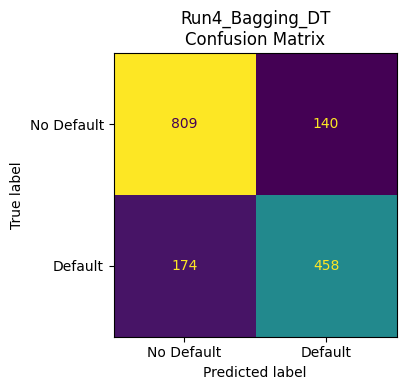

F1=0.7447 | AUC=0.8868
  Training AdaBoost ... 

2026/07/25 18:58:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


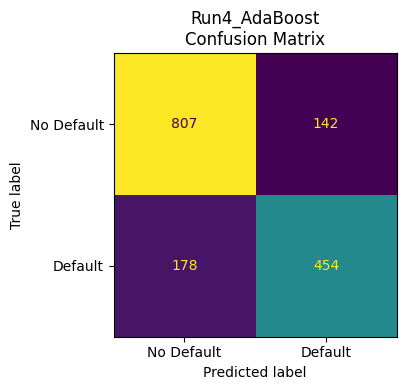

F1=0.7394 | AUC=0.8850
  Training Soft_Voting ... 

2026/07/25 18:58:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


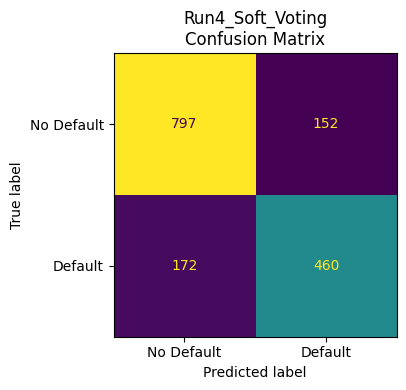

F1=0.7395 | AUC=0.8836
  Training Stacking ... 

2026/07/25 18:58:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


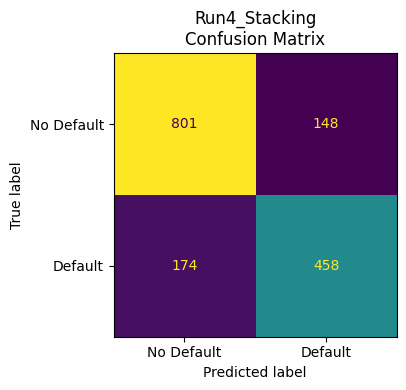

F1=0.7399 | AUC=0.8853

🏆 Ensemble Leaderboard:
             train_accuracy  test_accuracy  precision    recall  f1_score   roc_auc
Bagging_DT         0.851606       0.801392   0.765886  0.724684  0.744715  0.886843
Stacking           0.995412       0.796331   0.755776  0.724684  0.739903  0.885296
AdaBoost           0.825344       0.797596   0.761745  0.718354  0.739414  0.884997
Soft_Voting        0.932922       0.795066   0.751634  0.727848  0.739550  0.883640


In [27]:
print("═" * 60)
print(" 🎭  MLflow RUN 4 : Ensemble Learning")
print("═" * 60)

# ── 4a. Bagging ───────────────────────────────────────────────────────────────
bagging = BaggingClassifier(
    estimator    = DecisionTreeClassifier(max_depth=6),
    n_estimators = 100,
    max_samples  = 0.8,
    max_features = 0.8,
    random_state = 42,
    n_jobs       = -1
)

# ── 4b. AdaBoost ──────────────────────────────────────────────────────────────
adaboost = AdaBoostClassifier(
    estimator    = DecisionTreeClassifier(max_depth=3),
    n_estimators = 150,
    learning_rate= 0.08,
    random_state = 42
)

# ── 4c. Soft Voting (LR + RF + LightGBM) ─────────────────────────────────────
voter = VotingClassifier(
    estimators = [
        ('lr',  LogisticRegression(C=1.0, max_iter=300, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('lgbm',LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ],
    voting = 'soft',
    n_jobs = -1
)

# ── 4d. Stacking ──────────────────────────────────────────────────────────────
stacker = StackingClassifier(
    estimators = [
        ('dt',   DecisionTreeClassifier(max_depth=6, random_state=42)),
        ('rf',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ],
    final_estimator = LogisticRegression(C=1.0, random_state=42),
    cv    = 5,
    n_jobs= -1
)

ensembles = {
    'Bagging_DT'   : (bagging,  {'type': 'Bagging', 'n_estimators': 100, 'base': 'DecisionTree'}),
    'AdaBoost'     : (adaboost, {'type': 'Boosting', 'n_estimators': 150, 'base': 'DecisionTree'}),
    'Soft_Voting'  : (voter,    {'type': 'Voting', 'voting': 'soft', 'n_models': 3}),
    'Stacking'     : (stacker,  {'type': 'Stacking', 'meta_learner': 'LR', 'n_base': 3})
}

ensemble_scores = {}

for ens_name, (ens_model, ens_params) in ensembles.items():
    print(f"  Training {ens_name} ...", end=' ')
    ens_model.fit(X_train_sc, y_train)
    m = compute_metrics(ens_model, X_train_sc, y_train, X_test_sc, y_test)
    ensemble_scores[ens_name] = m
    log_metrics_and_model(
        run_name = f"Run4_{ens_name}",
        model    = ens_model,
        metrics  = m,
        params   = {**ens_params, 'run_type': 'ensemble_learning'},
        X_te     = X_test_sc,
        y_te     = y_test
    )
    print(f"F1={m['f1_score']:.4f} | AUC={m['roc_auc']:.4f}")

ens_df = pd.DataFrame(ensemble_scores).T.sort_values('roc_auc', ascending=False)
print("\n🏆 Ensemble Leaderboard:")
print(ens_df.to_string())

---
## 🏃 MLflow Run 5 — Data Improvement + Feature Engineering + PCA
> **Goal:** Enhance the dataset, engineer powerful features, reduce dimensionality with PCA, then retrain.

════════════════════════════════════════════════════════════
 🔬  MLflow RUN 5 : Data Improvement + FE + PCA + SMOTE
════════════════════════════════════════════════════════════
[1] Applying SMOTE to balance classes...
    Before SMOTE: {np.int64(0): np.int64(3792), np.int64(1): np.int64(2529)}
    After  SMOTE: {np.int64(0): np.int64(3792), np.int64(1): np.int64(3792)}
[2] Engineering new features on original X...
    New features added: credit_ltv_ratio, affordability_stress,
    amt_per_term_year, credit_score_gap, rate_spread, high_risk_flag
[3] Scaling enhanced feature set...
[4] Applying PCA — selecting components explaining 95% variance...
    Original features  : 31
    PCA components kept: 20 (95% variance explained)


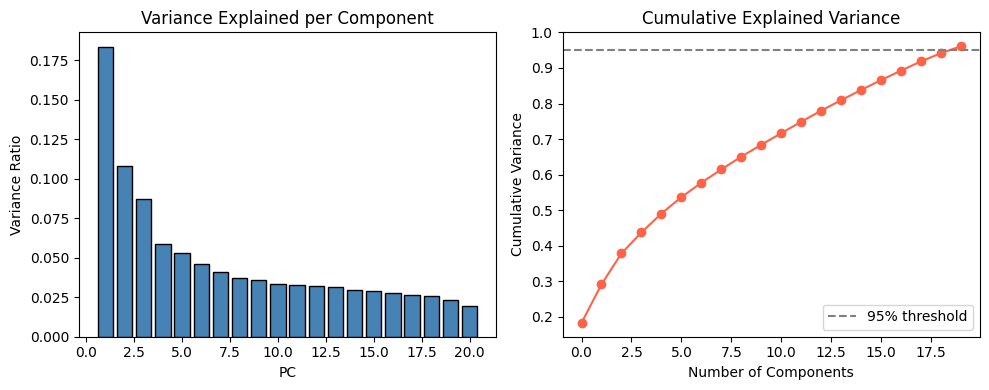

[5] Training Tuned XGBoost on improved dataset...


2026/07/25 18:59:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


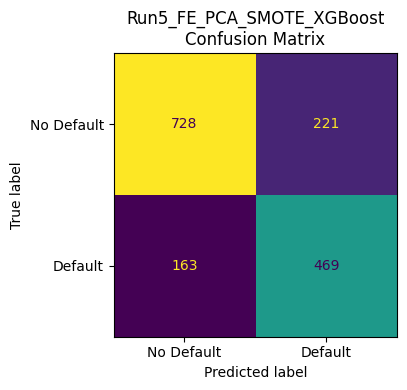


📊 Final Model (Run 5) Results:
   train_accuracy      : 0.8652
   test_accuracy       : 0.7571
   precision           : 0.6797
   recall              : 0.7421
   f1_score            : 0.7095
   roc_auc             : 0.8502


In [28]:
print("═" * 60)
print(" 🔬  MLflow RUN 5 : Data Improvement + FE + PCA + SMOTE")
print("═" * 60)

# ── Step A: SMOTE — Handle Class Imbalance ────────────────────────────────────
print("[1] Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f"    Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"    After  SMOTE: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")

# ── Step B: Feature Engineering ───────────────────────────────────────────────
print("[2] Engineering new features on original X...")
X_fe = X.copy()

# 1. Credit-to-LTV ratio — lower is riskier
X_fe['credit_ltv_ratio']    = X_fe['CSCORE_B'] / (X_fe['oltv'] + 1)
# 2. Affordability index — high DTI + high LTV = stressed borrower
X_fe['affordability_stress']= X_fe['dti'] * X_fe['oltv'] / 100
# 3. Loan amount per year of term
X_fe['amt_per_term_year']   = X_fe['orig_amt'] / (X_fe['orig_trm'] / 12 + 1)
# 4. Credit score gap between borrowers
X_fe['credit_score_gap']    = np.abs(X_fe['CSCORE_B'] - X_fe['CSCORE_MN'])
# 5. Rate spread above 3% threshold
X_fe['rate_spread']         = (X_fe['orig_rt'] - 3.0).clip(lower=0)
# 6. High-risk flag: DTI > 43% AND LTV > 80%
X_fe['high_risk_flag']      = ((X_fe['dti'] > 43) & (X_fe['oltv'] > 80)).astype(int)

print(f"    New features added: credit_ltv_ratio, affordability_stress,")
print(f"    amt_per_term_year, credit_score_gap, rate_spread, high_risk_flag")

# ── Step C: Re-scale after FE ─────────────────────────────────────────────────
print("[3] Scaling enhanced feature set...")
X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y)

scaler_fe = StandardScaler()
X_fe_train_sc = scaler_fe.fit_transform(X_fe_train)
X_fe_test_sc  = scaler_fe.transform(X_fe_test)

# Apply SMOTE on FE data
X_fe_sm, y_fe_sm = smote.fit_resample(X_fe_train_sc, y_fe_train)

# ── Step D: PCA ───────────────────────────────────────────────────────────────
print("[4] Applying PCA — selecting components explaining 95% variance...")
pca = PCA(n_components=0.95, random_state=42)
X_pca_train = pca.fit_transform(X_fe_sm)
X_pca_test  = pca.transform(X_fe_test_sc)
print(f"    Original features  : {X_fe_sm.shape[1]}")
print(f"    PCA components kept: {pca.n_components_} (95% variance explained)")

# Explained variance plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_, color='steelblue', edgecolor='black')
plt.title('Variance Explained per Component')
plt.xlabel('PC'); plt.ylabel('Variance Ratio')
plt.subplot(1, 2, 2)
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='tomato')
plt.axhline(0.95, linestyle='--', color='gray', label='95% threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

# ── Step E: Train Tuned XGBoost on PCA+SMOTE+FE Data ─────────────────────────
print("[5] Training Tuned XGBoost on improved dataset...")
final_xgb = XGBClassifier(
    **{k: v for k, v in best_xgb_params.items()},
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
final_xgb.fit(X_pca_train, y_fe_sm)
final_metrics = compute_metrics(final_xgb, X_pca_train, y_fe_sm, X_pca_test, y_fe_test)

run5_params = {
    **best_xgb_params,
    'run_type'        : 'data_improvement_FE_PCA',
    'SMOTE'           : True,
    'pca_components'  : int(pca.n_components_),
    'features_before_pca': X_fe_sm.shape[1],
    'new_features_added': 6
}

run_id_5 = log_metrics_and_model(
    run_name = "Run5_FE_PCA_SMOTE_XGBoost",
    model    = final_xgb,
    metrics  = final_metrics,
    params   = run5_params,
    X_te     = X_pca_test,
    y_te     = y_fe_test,
    flavor   = 'xgboost'
)
run_results.append(('Run5 – FE+PCA+SMOTE XGBoost', final_metrics, run_id_5))

print(f"\n📊 Final Model (Run 5) Results:")
for k, v in final_metrics.items():
    print(f"   {k:20s}: {v:.4f}")

---
## 📊 Final Summary: All Runs Compared


══════════════════════════════════════════════════════════════════════
 🏁  FINAL MLflow RUNS SUMMARY
══════════════════════════════════════════════════════════════════════
                              test_accuracy  precision  recall  f1_score  roc_auc
Run 1 – Baseline LR                  0.7812     0.7344  0.7089    0.7214   0.8522
Run 2 – Best Model (XGBoost)         0.7900     0.7373  0.7373    0.7373   0.8708
Run 3 – Tuned XGBoost                0.8071     0.7633  0.7500    0.7566   0.8934
Run 4 – Stacking Ensemble            0.7963     0.7558  0.7247    0.7399   0.8853
Run 5 – FE+PCA+SMOTE XGBoost         0.7571     0.6797  0.7421    0.7095   0.8502


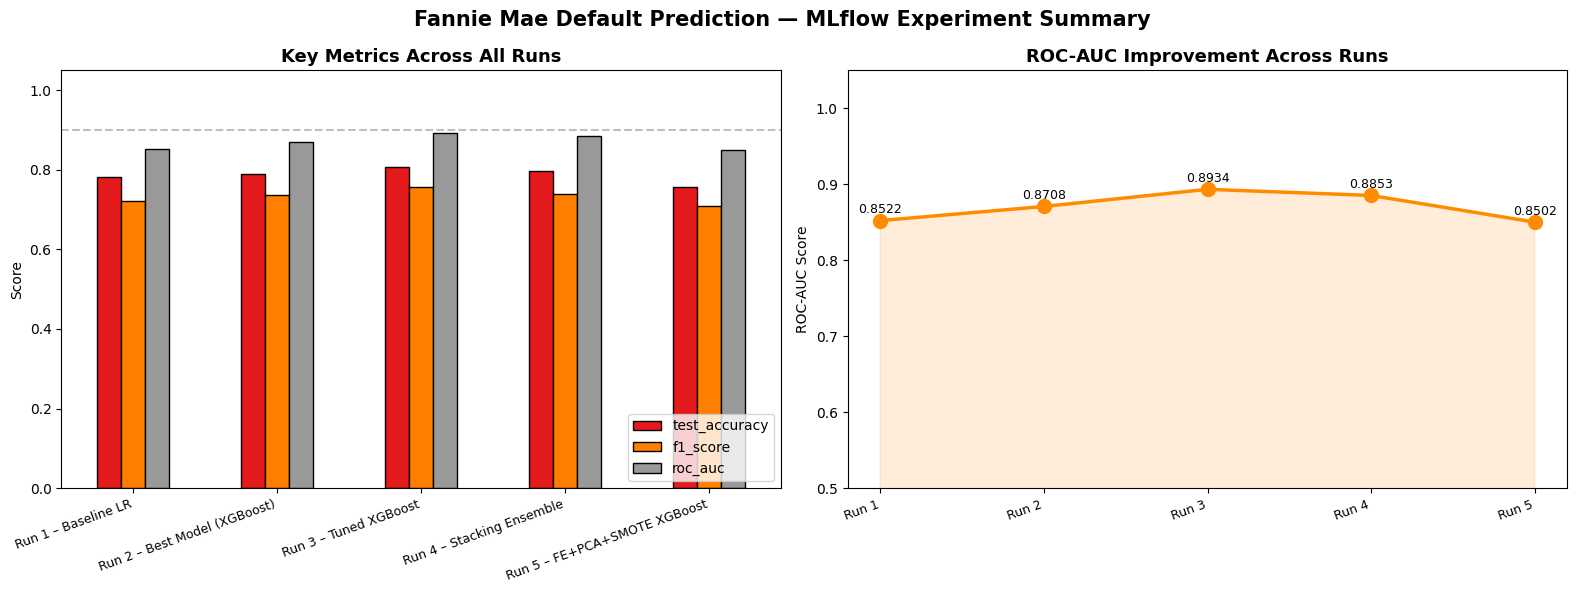


🥇 Best Overall Run : Run 3 – Tuned XGBoost
   ROC-AUC          : 0.8934
   F1-Score         : 0.7566


In [29]:
print("\n" + "═" * 70)
print(" 🏁  FINAL MLflow RUNS SUMMARY")
print("═" * 70)

all_runs = [
    ('Run 1 – Baseline LR',             lr_metrics),
    ('Run 2 – Best Model (XGBoost)',     comparison_results.get('XGBoost', {})),
    ('Run 3 – Tuned XGBoost',           tuned_metrics),
    ('Run 4 – Stacking Ensemble',        ensemble_scores.get('Stacking', {})),
    ('Run 5 – FE+PCA+SMOTE XGBoost',    final_metrics),
]

summary_df = pd.DataFrame(
    {name: m for name, m in all_runs if m}
).T[['test_accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']]

print(summary_df.to_string(float_format=lambda x: f'{x:.4f}'))

# ── Visual Summary ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_df[['test_accuracy', 'f1_score', 'roc_auc']].plot(
    kind='bar', ax=axes[0], edgecolor='black', colormap='Set1')
axes[0].set_title('Key Metrics Across All Runs', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right', fontsize=9)
axes[0].legend(loc='lower right')
axes[0].axhline(0.9, linestyle='--', color='gray', alpha=0.5)

summary_df['roc_auc'].plot(
    kind='line', marker='o', markersize=10, linewidth=2.5,
    color='darkorange', ax=axes[1])
axes[1].fill_between(range(len(summary_df)),
                     summary_df['roc_auc'].values, alpha=0.15, color='darkorange')
axes[1].set_title('ROC-AUC Improvement Across Runs', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_xticks(range(len(summary_df)))
axes[1].set_xticklabels([r.split('–')[0].strip() for r in summary_df.index],
                         rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0.5, 1.05)
for i, v in enumerate(summary_df['roc_auc']):
    axes[1].annotate(f'{v:.4f}', (i, v + 0.01), ha='center', fontsize=9)

plt.suptitle('Fannie Mae Default Prediction — MLflow Experiment Summary',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

best_run = summary_df['roc_auc'].idxmax()
print(f"\n🥇 Best Overall Run : {best_run}")
print(f"   ROC-AUC          : {summary_df.loc[best_run, 'roc_auc']:.4f}")
print(f"   F1-Score         : {summary_df.loc[best_run, 'f1_score']:.4f}")

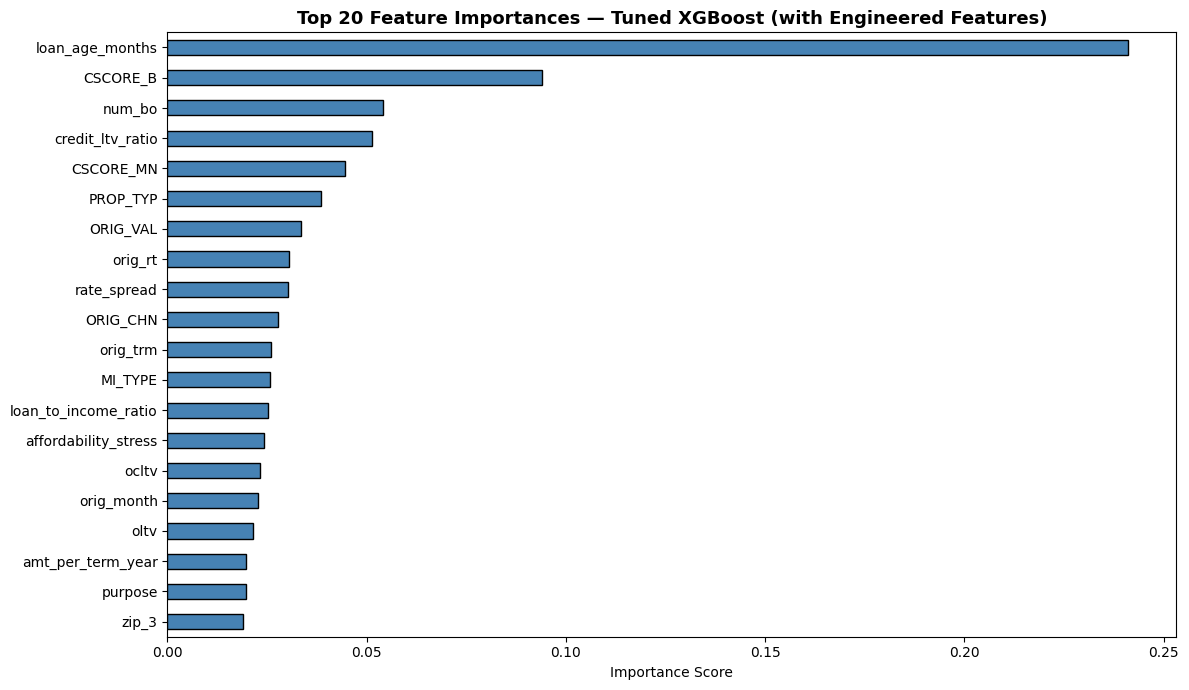


🔑 Top 10 Most Important Features:
   loan_age_months               : 0.2411
   CSCORE_B                      : 0.0941
   num_bo                        : 0.0540
   credit_ltv_ratio              : 0.0513
   CSCORE_MN                     : 0.0446
   PROP_TYP                      : 0.0386
   ORIG_VAL                      : 0.0336
   orig_rt                       : 0.0305
   rate_spread                   : 0.0302
   ORIG_CHN                      : 0.0276


In [30]:
# ── Feature Importance (Final Model before PCA) ────────────────────────────────
# Train one more time without PCA for interpretability
xgb_interp = XGBClassifier(
    **{k: v for k, v in best_xgb_params.items()},
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_interp.fit(X_fe_sm, y_fe_sm)

importances = pd.Series(
    xgb_interp.feature_importances_,
    index=X_fe.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances — Tuned XGBoost (with Engineered Features)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150)
plt.show()

print("\n🔑 Top 10 Most Important Features:")
for feat, score in importances.head(10).items():
    print(f"   {feat:30s}: {score:.4f}")

---
## 🚀 View Your MLflow Dashboard

Run this in your **terminal** to open the MLflow UI:
```bash
mlflow ui
```
Then open: **http://localhost:5000**

You will see all 5 runs under the experiment `Fannie_Mae_Default_Prediction` with:
- All metrics (accuracy, F1, ROC-AUC, precision, recall)
- All hyperparameters
- Confusion matrix artifacts
- Saved model artifacts

---
## ✅ Project Summary

| Step | Task | Technique |
|------|------|-----------|
| 1 | EDA | Distributions, Correlations, Class Balance |
| 2 | Data Cleaning | Date parsing, Encoding, Outlier clipping |
| 3 | Data Preparation | Train/Test split, StandardScaler |
| **Run 1** | **Baseline** | **Logistic Regression** |
| **Run 2** | **Model Selection** | **DT, RF, XGBoost, LightGBM, GBM** |
| **Run 3** | **Hyperparameter Tuning** | **RandomizedSearchCV + StratifiedKFold** |
| **Run 4** | **Ensemble Learning** | **Bagging, AdaBoost, Voting, Stacking** |
| **Run 5** | **Data Improvement + FE + PCA** | **SMOTE + 6 new features + PCA 95%** |